Original DataFrame 'id' type: object
Updated DataFrame 'id' type: object
Sample of original ids: 0    Line_16254
1     Line_6095
2     Line_6091
3    Line_16258
4    Line_16280
Name: id, dtype: object
Sample of updated ids: 0    Line_16280
1    Line_11813
2     Line_3057
3     Line_3060
4     Line_5644
Name: id, dtype: object
DEBUG: Merged shape = (1798, 65)


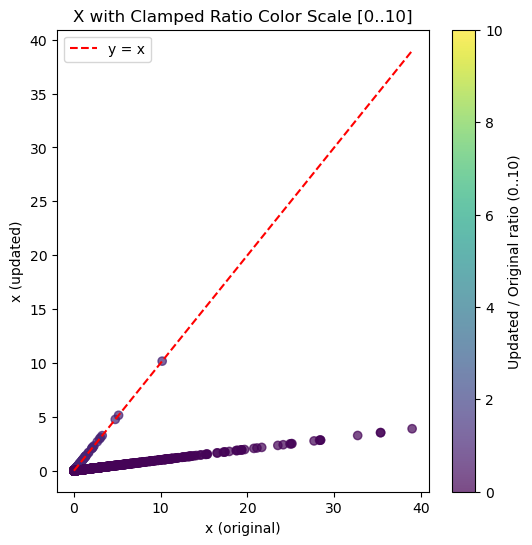

Plot for 'x' saved to lightsource/analysis_results_clamped_ratio/x_clamped_ratio.png. Ratio scale clamped to [0..10].


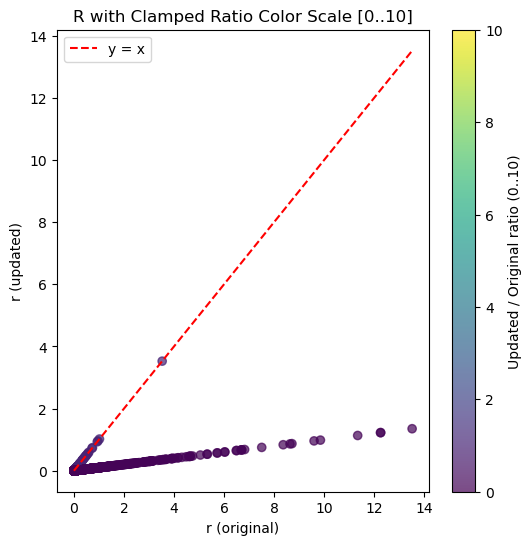

Plot for 'r' saved to lightsource/analysis_results_clamped_ratio/r_clamped_ratio.png. Ratio scale clamped to [0..10].


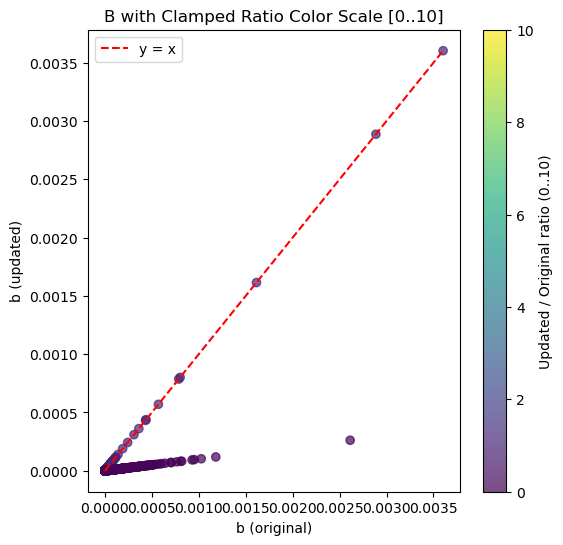

Plot for 'b' saved to lightsource/analysis_results_clamped_ratio/b_clamped_ratio.png. Ratio scale clamped to [0..10].


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Paths to your CSV files
lines_original_path = "lightsource/lines_original.csv"
lines_updated_path  = "lightsource/lines_updated.csv"

# Read the CSVs
original_df = pd.read_csv(lines_original_path)
updated_df  = pd.read_csv(lines_updated_path)

# Convert 'id' to string in both DataFrames before merging
original_df['id'] = original_df['id'].astype(str)
updated_df['id'] = updated_df['id'].astype(str)

# Print debug info
print("Original DataFrame 'id' type:", original_df['id'].dtype)
print("Updated DataFrame 'id' type:", updated_df['id'].dtype)
print("Sample of original ids:", original_df['id'].head())
print("Sample of updated ids:", updated_df['id'].head())

# Merge on the now-string 'id' column
df_merged = pd.merge(
    original_df,
    updated_df,
    on="id",
    suffixes=("_orig","_upd")
)
print("DEBUG: Merged shape =", df_merged.shape)

# Columns we want to compare
columns_to_compare = ["x", "r", "b"]
output_dir = "lightsource/analysis_results_clamped_ratio"
os.makedirs(output_dir, exist_ok=True)

for col in columns_to_compare:
    col_orig = f"{col}_orig"
    col_upd  = f"{col}_upd"

    # Make sure these columns exist in the merged DataFrame
    if col_orig not in df_merged.columns or col_upd not in df_merged.columns:
        print(f"Skipping {col}, columns not found in merged DataFrame.")
        continue

    # Convert to numeric
    df_merged[col_orig] = pd.to_numeric(df_merged[col_orig], errors="coerce")
    df_merged[col_upd]  = pd.to_numeric(df_merged[col_upd],  errors="coerce")

    # Filter rows: original must be > 0 to avoid division by zero
    mask = (~df_merged[col_orig].isna()) & (~df_merged[col_upd].isna()) & (df_merged[col_orig] > 0)
    df_compare = df_merged.loc[mask].copy()
    if df_compare.empty:
        print(f"No valid rows to compare ratio for '{col}'.")
        continue

    # Compute the raw ratio = updated / original
    raw_ratio_col = f"{col}_raw_ratio"
    df_compare[raw_ratio_col] = df_compare[col_upd] / df_compare[col_orig]

    # ------------------------------------------------------------
    # 1) SAVE ROWS WITH ratio >= 10 BEFORE CLAMPING
    # ------------------------------------------------------------
    big_mask = df_compare[raw_ratio_col] >= 10
    if big_mask.any():
        # Save these rows to a CSV
        big_ratio_csv = os.path.join(output_dir, f"{col}_ratio_gte10.csv")
        df_compare.loc[big_mask].to_csv(big_ratio_csv, index=False)
        print(f"Saved {big_mask.sum()} rows with ratio >= 10 for '{col}' to {big_ratio_csv}")

    # ------------------------------------------------------------
    # 2) CLAMP ratio to [0, 10] for plotting
    # ------------------------------------------------------------
    col_ratio_clamped = f"{col}_ratio_clamped"
    df_compare[col_ratio_clamped] = df_compare[raw_ratio_col].clip(lower=0, upper=10)

    # Plot scatter with color = clamped ratio
    plt.figure(figsize=(6,6))
    scatter = plt.scatter(
        df_compare[col_orig],
        df_compare[col_upd],
        c=df_compare[col_ratio_clamped],
        cmap="viridis",
        alpha=0.7,
        vmin=0,
        vmax=10
    )
    plt.colorbar(scatter, label="Updated / Original ratio (0..10)")

    # Diagonal line for reference
    min_val = min(df_compare[col_orig].min(), df_compare[col_upd].min())
    max_val = max(df_compare[col_orig].max(), df_compare[col_upd].max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="y = x")

    plt.title(f"{col.upper()} with Clamped Ratio Color Scale [0..10]")
    plt.xlabel(f"{col} (original)")
    plt.ylabel(f"{col} (updated)")
    plt.legend()
    
    # Display plot in notebook
    plt.show()

    # Save plot
    plot_path = os.path.join(output_dir, f"{col}_clamped_ratio.png")
    plt.savefig(plot_path)
    plt.close()

    print(f"Plot for '{col}' saved to {plot_path}. Ratio scale clamped to [0..10].")